# FER-2013 mini-Xception (CNN)

Trains the mini-Xception CNN on the 48×48 grayscale FER-2013 faces.

detect face (OpenCV Haar cascade) -> crop -> resize to 48×48 -> CNN inference **display label, confidence and ms**

The trained weights are saved to `models/mini_xception_fer2013.pt`.

## Requirements
- `pip install -U torch torchvision pandas scikit-learn scikit-image pillow kagglehub "opencv-python<5"`
- On Linux the `torch` wheel includes CUDA; training takes ~20 min on a laptop GPU 

In [1]:
# oNo Haar cascades on opencv 5 so stay on 4.x
%pip install -q torch torchvision pandas scikit-learn scikit-image pillow kagglehub "opencv-python<5"

Note: you may need to restart the kernel to use updated packages.


## Data

FER-2013 from Kaggle , stored as `data/{train,test}/<emotion>/*.jpg`. 

In [2]:
import shutil
from pathlib import Path

import torch
from torch import nn
from torchvision import datasets, transforms

DATA_DIR = Path('data')
MODEL_PATH = Path('models/mini_xception_fer2013.pt')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

if not (DATA_DIR / 'train').exists():
    import kagglehub
    shutil.copytree(kagglehub.dataset_download('msambare/fer2013'), DATA_DIR, dirs_exist_ok=True)

to_tensor = [transforms.ToTensor(), transforms.Normalize([0.5], [0.5])]  # faire [0, 255] -> [-1, 1]
train_tf = transforms.Compose([
    transforms.Grayscale(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    *to_tensor,
])
test_tf = transforms.Compose([transforms.Grayscale(), *to_tensor])

train_ds = datasets.ImageFolder(DATA_DIR / 'train', train_tf)
test_ds = datasets.ImageFolder(DATA_DIR / 'test', test_tf)
CLASSES = train_ds.classes
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=256)
print(f'Train: {len(train_ds)}  Test: {len(test_ds)}  Classes: {CLASSES}')

Device: cuda
Train: 28709  Test: 7178  Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Model

mini-Xception: two plain 3x3 convs, then four Xception blocks, then a 3x3 conv with one output map per class and global average pooling instead of fully connected layers.

In [3]:
class SeparableConv(nn.Sequential):
    """Depthwise 3x3 conv followed by a pointwise 1x1 conv."""
    def __init__(self, cin, cout):
        super().__init__(nn.Conv2d(cin, cin, 3, padding=1, groups=cin, bias=False),
                         nn.Conv2d(cin, cout, 1, bias=False))


class XceptionBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.main = nn.Sequential(
            SeparableConv(cin, cout), nn.BatchNorm2d(cout), nn.ReLU(),
            SeparableConv(cout, cout), nn.BatchNorm2d(cout),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.shortcut = nn.Sequential(nn.Conv2d(cin, cout, 1, stride=2, bias=False), nn.BatchNorm2d(cout))

    def forward(self, x):
        return self.main(x) + self.shortcut(x)


def mini_xception(num_classes=7):
    return nn.Sequential(
        nn.Conv2d(1, 8, 3, bias=False), nn.BatchNorm2d(8), nn.ReLU(),  # 48 -> 46
        nn.Conv2d(8, 8, 3, bias=False), nn.BatchNorm2d(8), nn.ReLU(),  # 46 -> 44
        XceptionBlock(8, 16), XceptionBlock(16, 32),                    # 44 -> 22 -> 11
        XceptionBlock(32, 64), XceptionBlock(64, 128),                  # 11 -> 6 -> 3
        nn.Conv2d(128, num_classes, 3, padding=1),                      # one map per class
        nn.AdaptiveAvgPool2d(1), nn.Flatten(),                          # global average pool -> logits
    )


model = mini_xception(len(CLASSES)).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 56,951


## Train (or load saved weights)

Adam with a cosine learning-rate schedule for a fixed number of epochs. Test accuracy is printed only to monitor progress: the final model is simply the last epoch, so nothing is selected on the test set.

Delete `models/mini_xception_fer2013.pt` to retrain.

In [4]:
EPOCHS = 60


def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.append(model(x.to(device)).argmax(1).cpu())
            labels.append(y)
    return torch.cat(preds), torch.cat(labels)


if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print('Loaded weights from', MODEL_PATH)
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS)
    loss_fn = nn.CrossEntropyLoss()
    for epoch in range(EPOCHS):
        model.train()
        total_loss, correct = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
        scheduler.step()
        preds, labels = evaluate(model, test_loader)
        print(f'epoch {epoch + 1:2d}/{EPOCHS}  loss {total_loss / len(train_ds):.3f}  '
              f'train acc {correct / len(train_ds):.3f}  test acc {(preds == labels).float().mean():.3f}')
    MODEL_PATH.parent.mkdir(exist_ok=True)
    torch.save(model.state_dict(), MODEL_PATH)
    print('Saved weights to', MODEL_PATH)

Loaded weights from models/mini_xception_fer2013.pt


## Test-set evaluation

In [5]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

preds, labels = evaluate(model, test_loader)
print(f'Test accuracy: {(preds == labels).float().mean():.4f}\n')
print(classification_report(labels, preds, target_names=CLASSES, digits=3))
pd.DataFrame(confusion_matrix(labels, preds), index=CLASSES, columns=CLASSES).rename_axis(index='true', columns='predicted')

Test accuracy: 0.6335

              precision    recall  f1-score   support

       angry      0.551     0.559     0.555       958
     disgust      0.629     0.396     0.486       111
        fear      0.472     0.368     0.414      1024
       happy      0.826     0.864     0.844      1774
     neutral      0.562     0.655     0.605      1233
         sad      0.519     0.486     0.502      1247
    surprise      0.734     0.775     0.754       831

    accuracy                          0.633      7178
   macro avg      0.613     0.586     0.594      7178
weighted avg      0.626     0.633     0.628      7178



predicted,angry,disgust,fear,happy,neutral,sad,surprise
true,,,,,,,
angry,536,8,96,47,120,122,29
disgust,35,44,11,3,4,13,1
fear,137,5,377,48,142,198,117
happy,29,1,21,1532,90,50,51
neutral,81,2,64,105,808,153,20
sad,131,8,154,84,249,606,15
surprise,23,2,76,36,25,25,644


## Per-frame pipeline

detect faces (Haar cascade) -> crop each box -> resize to 48×48 -> normalize exactly like training -> CNN -> softmax. Each face is labelled with its emotion, confidence (softmax probability) and the crop + inference time in ms; the top-left corner shows the whole frame time, detection included.

In [6]:
import time

import cv2
import numpy as np

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
model.eval()


def predict_face(gray_face):
    """Resize a grayscale face crop to 48x48 and classify it. Returns (label, confidence)."""
    face = cv2.resize(gray_face, (48, 48), interpolation=cv2.INTER_AREA)
    x = torch.from_numpy(face).float().div(255).sub(0.5).div(0.5)[None, None].to(device)
    with torch.no_grad():
        probs = model(x).softmax(1)[0].cpu()
    conf, idx = probs.max(0)
    return CLASSES[idx], conf.item()


def process_frame(frame):
    """Detect -> crop -> resize -> classify every face in a BGR frame, and draw the results on it."""
    start = time.perf_counter()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(48, 48))
    for x, y, w, h in faces:
        t = time.perf_counter()
        label, conf = predict_face(gray[y:y + h, x:x + w])
        ms = (time.perf_counter() - t) * 1000
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, f'{label} {conf:.0%} {ms:.1f}ms', (x, max(y - 8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    total_ms = (time.perf_counter() - start) * 1000
    cv2.putText(frame, f'frame {total_ms:.1f}ms', (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    return frame


predict_face(np.zeros((48, 48), np.uint8))  # warm-up because cuda start-up is slow, so the first timing is not representative

('angry', 0.7279891967773438)

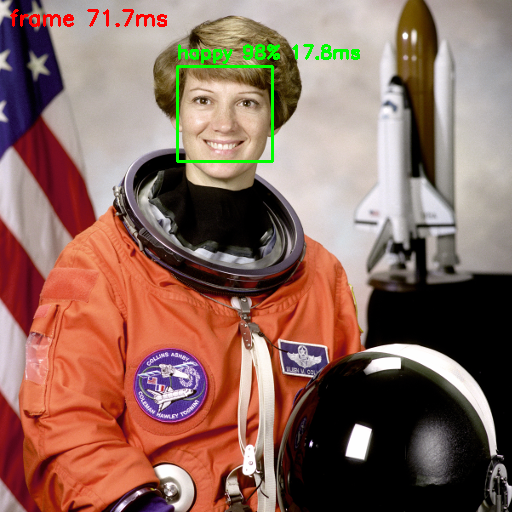

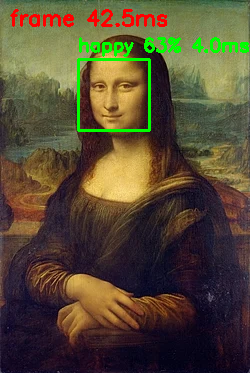

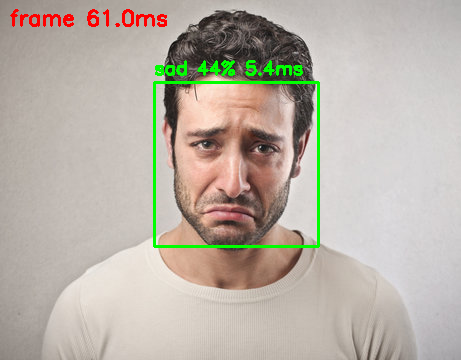

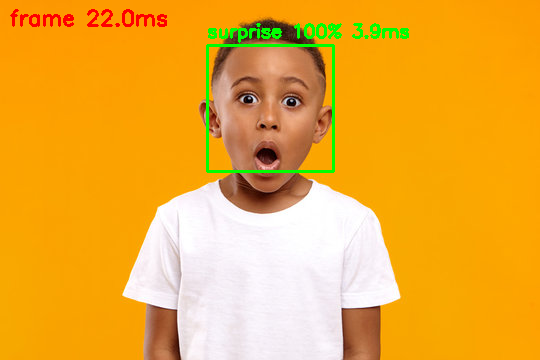

In [8]:
from IPython.display import display
from PIL import Image
from skimage import data

# Demo on sample photo bundled with scikit-image (RGB, so convert to OpenCV's BGR)
frame = process_frame(cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR))
display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))


frame = process_frame(cv2.imread('monalisa.webp'))
display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

frame = process_frame(cv2.imread('sad.jpg'))
display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

frame = process_frame(cv2.imread('surprised.jpg'))
display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

### Live webcam

Opens a window with the annotated video; press **q** in that window to stop.

In [10]:
cap = cv2.VideoCapture(0)
try:
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        cv2.imshow('mini-Xception FER (q to quit)', process_frame(frame))
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()

## Notes

- The Haar cascade only finds roughly frontal, upright faces, which is also what FER-2013 contains.
- Confidence is the softmax probability of the predicted class: useful for ranking, but not calibrated.
- FER-2013 labels are noisy (human accuracy is about 65%), and `disgust` has very few training images, so expect weak recall on that class.